In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
from scipy.signal import butter, filtfilt, resample_poly, resample, find_peaks
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns
from scipy.stats import wilcoxon

# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

In [64]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"
BLRI_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5"
BLRI_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5"
BLRI_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5"
BLRI_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5"
#BLRI_3_5_h5_path = rmissing h5
BLRI_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"     
BLRI_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5"


# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
RI1_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv")
RI2_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv")
RI1_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv")
RI2_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv")
RI1_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv")
RI2_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv")
RI1_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv")
RI2_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv")
RI1_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv")
RI2_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv")
RI2_3_5_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv")


In [65]:
ri1_h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
}

ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}

h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
    "BLRI_1_1": BLRI_1_1_h5_path,
    "BLRI_1_2": BLRI_1_2_h5_path,
    "BLRI_2_3": BLRI_2_3_h5_path,
    "BLRI_2_4": BLRI_2_4_h5_path,
    #"BLRI_3_5": BLRI_3_5_h5_path,
    "BLRI_3_6": BLRI_3_6_h5_path,
    "BLRI_4_7": BLRI_4_7_h5_path,
    "BLRI_4_8": BLRI_4_8_h5_path,
}


In [66]:
ri1_boris_data = {
    "RI1_3_6": RI1_3_6_boris.copy(),
    "RI1_4_7": RI1_4_7_boris.copy(),
    "RI1_2_3": RI1_2_3_boris.copy(),
    "RI1_4_8": RI1_4_8_boris.copy(),
    "RI1_1_1": RI1_1_1_boris.copy(),
    "RI1_1_2": RI1_1_2_boris.copy(),
    "RI1_2_4": RI1_2_4_boris.copy(),
}

ri2_boris_data = {
    "RI2_3_6": RI2_3_6_boris.copy(),
    "RI2_4_7": RI2_4_7_boris.copy(),
    "RI2_2_3": RI2_2_3_boris.copy(),
    "RI2_4_8": RI2_4_8_boris.copy(),
    "RI2_1_1": RI2_1_1_boris.copy(),
    "RI2_1_2": RI2_1_2_boris.copy(),
    "RI2_2_4": RI2_2_4_boris.copy(),
    "RI2_3_5": RI2_3_5_boris.copy(),
}

In [67]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Load respiration from .h5, anti-alias LPF at raw fs, resample to target_rate,
    band-pass clean, and return (signal, time, fs_out).
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = float(ekg_meta['duration_sec'])
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # --- Anti-alias LPF at raw fs ---
    if target_rate >= fs:
        # No decimation needed; still low-pass a bit to remove HF noise
        cutoff_hz = min(0.45 * fs, 20.0)  # keep it sensible if fs is small
        Wn = cutoff_hz / (fs / 2.0)
    else:
        cutoff_hz = target_rate / 2.0       # classic anti-alias cutoff
        Wn = cutoff_hz / (fs / 2.0)

    Wn = min(max(Wn, 0.0001), 0.9999)       # clamp for safety
    b, a = butter(N=4, Wn=Wn, btype='low')
    filtered = filtfilt(b, a, resp)

    # --- Resample to EXACT target_rate ---
    # Prefer exact-length resample to avoid floor issues
    N_out = int(round(duration_sec * target_rate))
    # If you prefer polyphase, use Fraction to get integers:
    # from fractions import Fraction
    # frac = Fraction(target_rate, int(round(fs))).limit_denominator()
    # resampled = resample_poly(filtered, up=frac.numerator, down=frac.denominator)
    resampled = sp.signal.resample(filtered, N_out)

    # --- Final band-pass clean at the new fs ---
    # Keep physiological band; adjust if you know your spectrum well
    lowcut, highcut = 0.1, 15.0
    rsp_cleaned = nk.signal_filter(
        resampled, lowcut=lowcut, highcut=highcut,
        method="butterworth", sampling_rate=target_rate, order=2
    )

    time_vector = np.arange(len(rsp_cleaned)) / float(target_rate)  # ✅ correct
    return rsp_cleaned, time_vector, float(target_rate)

In [68]:
resp_data = {}

for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("✅ All available signals loaded.")

Processing RI1_3_6...
Processing RI2_3_6...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...
Processing RI1_1_1...
Processing RI2_1_1...
Processing RI1_1_2...
Processing RI2_1_2...
Processing RI1_2_4...
Processing RI2_2_4...
Processing RI1_3_5...
Processing RI2_3_5...
Processing BLRI_1_1...
Processing BLRI_1_2...
Processing BLRI_2_3...
Processing BLRI_2_4...
Processing BLRI_3_6...
Processing BLRI_4_7...
Processing BLRI_4_8...
✅ All available signals loaded.


In [69]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

def plot_resp_with_behaviors(resp_dict, boris_df, session_label,
                             behaviors_to_plot=None, window=None,
                             smooth_win=5):
    """
    Plot respiration trace + instantaneous frequency with behavior epochs.

    Parameters
    ----------
    resp_dict : dict
        Contains 'signal', 'time', 'sampling_rate' for the session.
    boris_df : pd.DataFrame
        BORIS annotations with ['Behavior','Start (s)','Stop (s)'].
    session_label : str
        Label for the session.
    behaviors_to_plot : list or None
        Behaviors to overlay. If None, all in BORIS df will be shown.
    window : tuple or None
        (start, stop) time in seconds to zoom in.
    smooth_win : int
        Window (in samples) for smoothing instantaneous rate.
    """

    signal = resp_dict["signal"]
    time = resp_dict["time"]
    fs = resp_dict["sampling_rate"]

    # Apply zoom window if given
    if window:
        mask = (time >= window[0]) & (time <= window[1])
        signal = signal[mask]
        time = time[mask]
        boris_df = boris_df[
            (boris_df["Start (s)"] <= window[1]) & (boris_df["Stop (s)"] >= window[0])
        ]

    # --- Compute instantaneous breathing frequency ---
    # detect peaks in the respiration trace
    min_dist = int(0.0833 * fs)  # ~12 Hz max breathing rate
    peaks, _ = find_peaks(signal, distance=min_dist)
    ibi = np.diff(time[peaks])  # inter-breath intervals
    inst_rate = 1.0 / ibi       # Hz
    inst_t = time[peaks][1:]    # align with intervals

    # smooth the instantaneous rate
    if smooth_win > 1:
        kernel = np.ones(smooth_win) / smooth_win
        inst_rate = np.convolve(inst_rate, kernel, mode="same")

    # --- Plot ---
    fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

    # Colors for behaviors
    if behaviors_to_plot is None:
        behaviors_to_plot = boris_df["Behavior"].unique()
    colors = plt.cm.tab20.colors
    color_map = {b: colors[i % len(colors)] for i, b in enumerate(behaviors_to_plot)}

    # Top: respiration trace
    axes[0].plot(time, signal, color="black", lw=1)
    for _, row in boris_df.iterrows():
        if row["Behavior"] in behaviors_to_plot:
            axes[0].axvspan(row["Start (s)"], row["Stop (s)"],
                            color=color_map[row["Behavior"]], alpha=0.3)
    axes[0].set_ylabel("Respiration (a.u.)")
    axes[0].set_title(f"{session_label}: Respiration trace with behaviors")

    # Bottom: instantaneous frequency
    axes[1].plot(inst_t, inst_rate, color="darkred", lw=1.5, label="Breathing rate (Hz)")
    for _, row in boris_df.iterrows():
        if row["Behavior"] in behaviors_to_plot:
            axes[1].axvspan(row["Start (s)"], row["Stop (s)"],
                            color=color_map[row["Behavior"]], alpha=0.3)
    axes[1].set_ylabel("Rate (Hz)")
    axes[1].set_xlabel("Time (s)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()



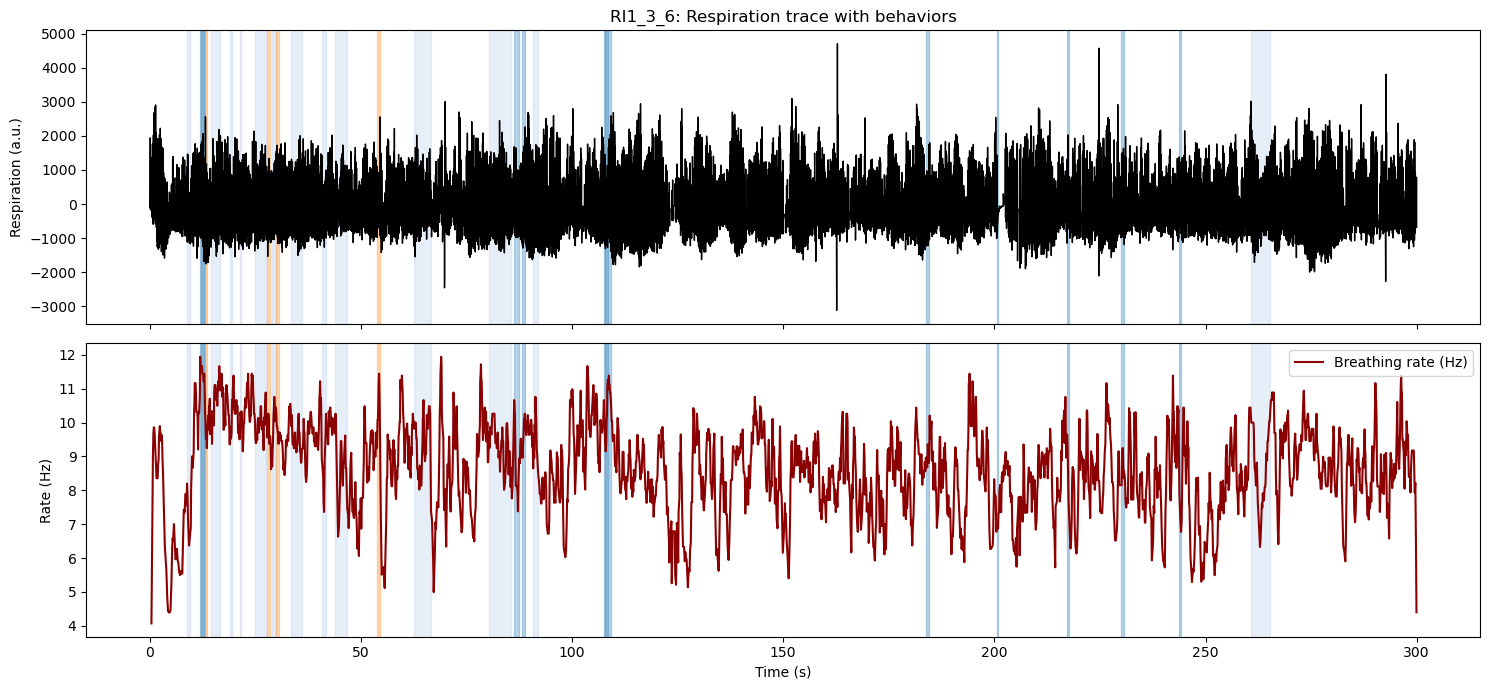

In [70]:
plot_resp_with_behaviors(
    resp_data["RI1_3_6"],
    ri1_boris_data["RI1_3_6"],
    session_label="RI1_3_6",
    behaviors_to_plot=["facial sniffing", "anogenital sniffing","body sniffing"],
    window=(0, 300)
)


In [71]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute average breathing rate (Hz) within a time window.

    Parameters
    ----------
    signal : array
        Respiration signal.
    time : array
        Time vector (seconds).
    sniff_start, sniff_end : float
        Start and end of window (can be a behavioral bout or full trial).
    sampling_rate : float
        Sampling rate of the signal (Hz). Default=100.

    Returns
    -------
    rate : float
        Average respiration rate (Hz) across the window.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # ≥12 Hz refractory
    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate


In [79]:
ri_session_rates = []

for trial, entry in resp_data.items():
    signal = entry['signal']
    time = entry['time']
    sampling_rate = entry['sampling_rate']

    # Get full duration
    sniff_start = time[0]
    sniff_end = time[-1]

    # Compute respiration rate
    rate = get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=sampling_rate)

    # Assign valence (skip if not RI1/RI2)
    if trial.startswith('RI1'):
        valence = "Positive"
    elif trial.startswith('RI2'):
        valence = "Negative"
    else:
        continue  # skip anything that's not RI1/RI2

    # Extract subject as 3.6 from RI1_3_6
    try:
        parts = trial.split('_')
        subject = f"{parts[1]}.{parts[2]}"
    except IndexError:
        subject = 'Unknown'

    ri_session_rates.append({
        'Trial': trial,
        'Valence': valence,
        'Subject': subject,
        'Respiration Rate (Hz)': rate
    })

# Convert to DataFrame
ri_session_df = pd.DataFrame(ri_session_rates)
ri_session_df


,Trial,Valence,Subject,Respiration Rate (Hz)
0,RI1_3_6,Positive,3.6,7.371614
1,RI2_3_6,Negative,3.6,5.942720
2,RI1_4_7,Positive,4.7,7.750139
3,RI2_4_7,Negative,4.7,6.559377
4,RI1_2_3,Positive,2.3,7.337380
5,RI2_2_3,Negative,2.3,6.687569
6,RI1_4_8,Positive,4.8,7.557495
7,RI2_4_8,Negative,4.8,5.778890
8,RI1_1_1,Positive,1.1,7.517103
9,RI2_1_1,Negative,1.1,6.020371


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30284\1769557175.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='Valence', ylabel='Respiration Rate (Hz)'>

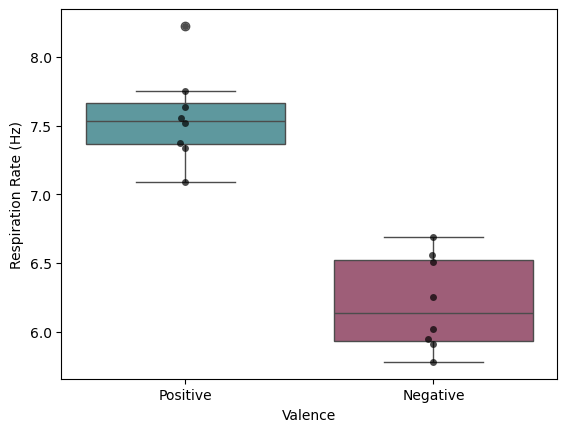

In [80]:
sns.boxplot(
    data=ri_session_df, x="Valence", y="Respiration Rate (Hz)",
    palette=custom_palette
)
sns.swarmplot(
    data=ri_session_df, x="Valence", y="Respiration Rate (Hz)",
    color="black", alpha=0.7
)


In [84]:
from scipy.stats import wilcoxon

pivot = ri_session_df.pivot(index="Subject", columns="Valence", values="Respiration Rate (Hz)").dropna()
stat, pval = wilcoxon(pivot["Positive"], pivot["Negative"])
print(f"Wilcoxon test: stat={stat}, p={pval}")


Wilcoxon test: stat=0.0, p=0.0078125
